# CardioIA — Classificador de risco

Classifica frases de pacientes em **alto risco** ou **baixo risco**.

> No Colab, suba o `frases_risco.csv` antes de rodar.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## 1. Dados

62 frases, metade de cada classe.

In [4]:
df = pd.read_csv("frases_risco.csv")
print(df.shape)
df["situacao"].value_counts()

(62, 2)


,count
situacao,
alto risco,31
baixo risco,31


In [5]:
df.sample(6, random_state=1)

,frase,situacao
21,tenho dor muscular no ombro desde a academia,baixo risco
52,tenho inchaço nas pernas e ganhei três quilos ...,alto risco
38,estou com suor frio enjoo e dor nas costas que...,alto risco
24,meu braço esquerdo ficou dormente junto com do...,alto risco
2,sinto uma dor forte no peito que vai para o br...,alto risco
41,tenho dor nas costas por ficar muitas horas no...,baixo risco


## 2. Treino e teste

75% treino, 25% teste.

In [6]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    df["frase"], df["situacao"],
    test_size=0.25, stratify=df["situacao"], random_state=42
)
print(len(X_treino), "frases de treino /", len(X_teste), "de teste")

46 frases de treino / 16 de teste


## 3. TF-IDF

Transforma cada frase em um vetor de pesos por palavra.

In [7]:
vetorizador = TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2))
X_treino_vet = vetorizador.fit_transform(X_treino)
X_teste_vet = vetorizador.transform(X_teste)

# frases x termos do vocabulário
print(X_treino_vet.shape)

(46, 482)


## 4. Modelos

Regressão Logística vs. Árvore de Decisão.

In [8]:
modelos = {
    "Regressão Logística": LogisticRegression(),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
}

for nome, modelo in modelos.items():
    modelo.fit(X_treino_vet, y_treino)
    previsto = modelo.predict(X_teste_vet)
    print(f"{nome}: acurácia de {accuracy_score(y_teste, previsto):.0%}")

Regressão Logística: acurácia de 75%
Árvore de Decisão: acurácia de 56%


## 5. Avaliação

Na triagem, o pior erro é classificar alto risco como baixo.

In [9]:
modelo = modelos["Regressão Logística"]
previsto = modelo.predict(X_teste_vet)
print(classification_report(y_teste, previsto))

              precision    recall  f1-score   support

  alto risco       0.75      0.75      0.75         8
 baixo risco       0.75      0.75      0.75         8

    accuracy                           0.75        16
   macro avg       0.75      0.75      0.75        16
weighted avg       0.75      0.75      0.75        16



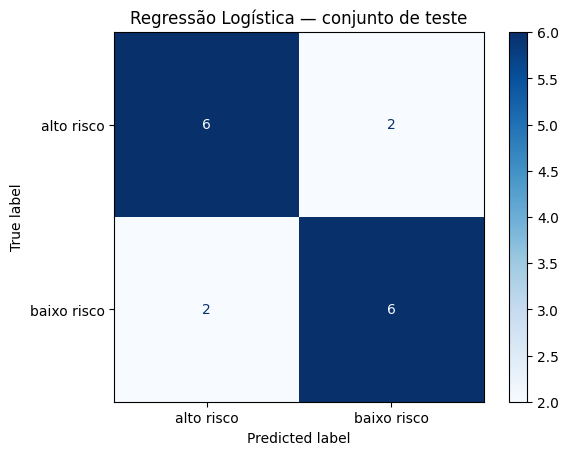

In [10]:
ConfusionMatrixDisplay.from_predictions(y_teste, previsto, cmap="Blues")
plt.title("Regressão Logística — conjunto de teste")
plt.show()

Validação cruzada: resultado mais estável com poucos dados.

In [11]:
for nome, modelo_base in modelos.items():
    pipe = make_pipeline(TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2)), modelo_base)
    notas = cross_val_score(pipe, df["frase"], df["situacao"], cv=5)
    print(f"{nome}: média {notas.mean():.0%} (variando de {notas.min():.0%} a {notas.max():.0%})")

Regressão Logística: média 79% (variando de 67% a 100%)
Árvore de Decisão: média 77% (variando de 67% a 92%)


## 6. Frases novas

Inclui pegadinhas: negação, "leve" e outra pessoa.

In [12]:
frases_novas = [
    "estou com uma dor muito forte no peito e suando",
    "tive uma leve dor de cabeça hoje de manhã",
    "sinto o coração disparado e falta de ar",
    "estou cansado depois de um dia longo",
    "não sinto dor no peito nem falta de ar",
    "tive uma dor no peito leve que passou rápido",
    "minha mãe está com dor no peito",
    "estou bem, só vim fazer exames de rotina",
]

vetores = vetorizador.transform(frases_novas)
previsoes = modelo.predict(vetores)
# probabilidade da classe alto risco
prob_alto = modelo.predict_proba(vetores)[:, list(modelo.classes_).index("alto risco")]

pd.DataFrame({"frase": frases_novas, "previsão": previsoes, "prob. alto risco": prob_alto.round(2)})

,frase,previsão,prob. alto risco
0,estou com uma dor muito forte no peito e suando,alto risco,0.63
1,tive uma leve dor de cabeça hoje de manhã,baixo risco,0.46
2,sinto o coração disparado e falta de ar,alto risco,0.60
3,estou cansado depois de um dia longo,baixo risco,0.33
4,não sinto dor no peito nem falta de ar,alto risco,0.66
5,tive uma dor no peito leve que passou rápido,alto risco,0.59
6,minha mãe está com dor no peito,alto risco,0.66
7,"estou bem, só vim fazer exames de rotina",baixo risco,0.44


## 7. Palavras que mais pesam

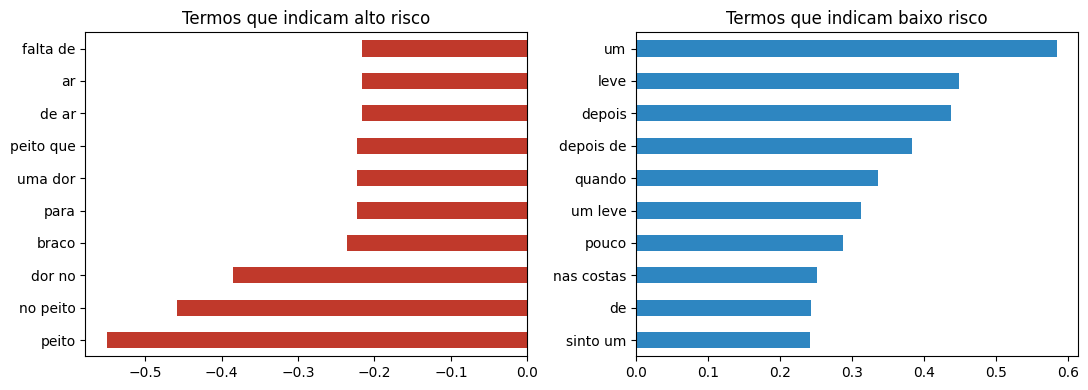

In [13]:
pesos = pd.Series(modelo.coef_[0], index=vetorizador.get_feature_names_out()).sort_values()

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
pesos.head(10).plot.barh(ax=eixos[0], color="#c0392b", title="Termos que indicam alto risco")
pesos.tail(10).plot.barh(ax=eixos[1], color="#2e86c1", title="Termos que indicam baixo risco")
plt.tight_layout()
plt.show()

## 8. Limitações

- **Ignora negação:** "não sinto dor no peito" parece "sinto dor no peito".
- **"Leve" vira atalho:** dor leve no peito ainda pode ser grave.
- **Vocabulário de uma pessoa só:** gírias e expressões regionais podem falhar.
- **Poucos dados:** acurácia alta aqui não garante uso real.
- **Sem contexto clínico:** idade, histórico e sinais vitais ficam de fora.